# Penugasan No. 3: Fitur Berbeda untuk CBIR — Mean Color vs Histogram

## Tujuan
Membandingkan dua pendekatan fitur visual untuk CBIR:

| Fitur | Dimensi | Metrik Jarak |
|---|---|---|
| **Histogram Warna RGB** (Praktikum 5) | 48 dimensi (16 bin × 3 channel) | Cosine Distance |
| **Rata-rata Warna RGB** (Penugasan ini) | 3 dimensi (mean R, mean G, mean B) | Euclidean Distance (L2) |

## Konsep Rata-rata Warna (Mean Color)
Setiap citra diringkas menjadi hanya **3 angka**:
- `mean_R` → rata-rata intensitas channel merah
- `mean_G` → rata-rata intensitas channel hijau
- `mean_B` → rata-rata intensitas channel biru

Ini adalah representasi fitur yang **paling sederhana** — sangat efisien namun
kehilangan banyak informasi distribusi warna dibanding histogram.

## Pertanyaan Utama
> Apakah fitur 3 dimensi (mean color) cukup untuk membedakan citra-citra
> dalam database, atau histogram 48 dimensi memberikan hasil yang lebih baik?

Memproses database citra...
  ✔ astronaut | mean RGB = (0.555, 0.415, 0.378)
  ✔ camera | mean RGB = (0.506, 0.506, 0.506)
  ✔ coffee | mean RGB = (0.622, 0.336, 0.202)
  ✔ coins | mean RGB = (0.380, 0.380, 0.380)
  ✔ chelsea | mean RGB = (0.579, 0.437, 0.340)


C:\Users\LATIFA\AppData\Local\Temp\ipykernel_30796\3482556318.py:109: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0.06, 0, 1, 0.95])
e:\SEMESTER 6\Pengolahan Citra\Weekly Task\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


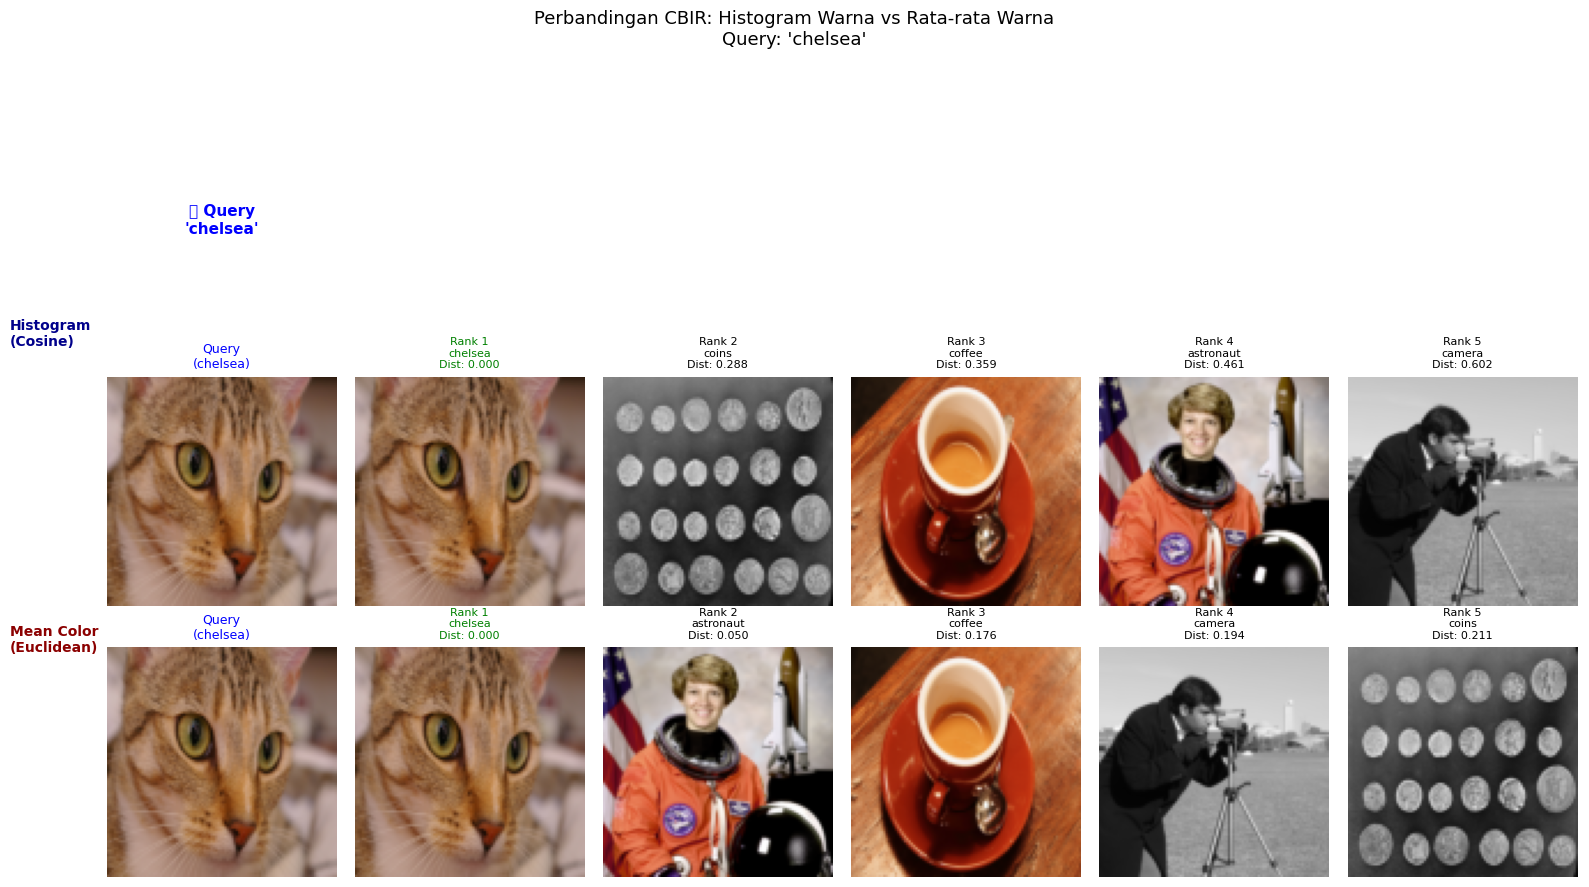


       CBIR — Histogram Warna (Cosine Distance)        
Rank   Nama          Cosine Dist
-------------------------------------------------------
  1     chelsea            0.0000 ← QUERY
  2     coins              0.2879
  3     coffee             0.3593
  4     astronaut          0.4612
  5     camera             0.6020

        CBIR — Mean Color (Euclidean Distance)         
Rank   Nama         Euclidean Dist
-------------------------------------------------------
  1     chelsea              0.0000 ← QUERY
  2     astronaut            0.0501
  3     coffee               0.1765
  4     camera               0.1938
  5     coins                0.2110


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color, transform, img_as_float, img_as_ubyte
from scipy.spatial import distance

# ── Fungsi Fitur 1: Histogram Warna (dari Praktikum 5) ───────────────────────
def calculate_rgb_histogram(image, bins=16):
    if image.dtype == float or image.max() <= 1.0:
        image = img_as_ubyte(np.clip(image, 0, 1))
    hist_r, _ = np.histogram(image[:,:,0].ravel(), bins=bins, range=(0, 256))
    hist_g, _ = np.histogram(image[:,:,1].ravel(), bins=bins, range=(0, 256))
    hist_b, _ = np.histogram(image[:,:,2].ravel(), bins=bins, range=(0, 256))
    hist_combined = np.concatenate((hist_r, hist_g, hist_b)).astype(float)
    hist_sum = np.sum(hist_combined)
    if hist_sum > 0:
        hist_combined /= hist_sum
    return hist_combined

# ── Fungsi Fitur 2: Rata-rata Warna RGB (Mean Color) ─────────────────────────
def calculate_mean_color(image):
    # Pastikan float [0, 1]
    img = img_as_float(image)
    mean_r = np.mean(img[:, :, 0])
    mean_g = np.mean(img[:, :, 1])
    mean_b = np.mean(img[:, :, 2])
    return np.array([mean_r, mean_g, mean_b])

# ── Siapkan Database ──────────────────────────────────────────────────────────
image_db_names  = ["astronaut", "camera", "coffee", "coins", "chelsea"]
database_images = []
database_hists  = []
database_means  = []

print("Memproses database citra...")
for name in image_db_names:
    img = getattr(data, name)()
    if img.ndim == 2:
        img = color.gray2rgb(img)
    img_resized = transform.resize(img, (100, 100), anti_aliasing=True)
    database_images.append(img_resized)
    database_hists.append(calculate_rgb_histogram(img_resized))
    database_means.append(calculate_mean_color(img_resized))
    print(f"  ✔ {name} | mean RGB = ({database_means[-1][0]:.3f}, "
          f"{database_means[-1][1]:.3f}, {database_means[-1][2]:.3f})")

# ── Query Image ───────────────────────────────────────────────────────────────
query_name  = "chelsea"
query_index = image_db_names.index(query_name)
query_image = database_images[query_index]
query_hist  = database_hists[query_index]
query_mean  = database_means[query_index]

# ── Hitung Jarak ──────────────────────────────────────────────────────────────
dist_cosine    = [distance.cosine(query_hist, h) for h in database_hists]
dist_euclidean = [distance.euclidean(query_mean, m) for m in database_means]

sorted_hist = np.argsort(dist_cosine)
sorted_mean = np.argsort(dist_euclidean)

# ── Visualisasi Perbandingan ──────────────────────────────────────────────────
fig, axes = plt.subplots(3, len(database_images) + 1, figsize=(16, 9))

# Baris 0: Label
axes[0, 0].text(0.5, 0.5, f"🔍 Query\n'{query_name}'",
                ha='center', va='center', fontsize=11, color='blue',
                fontweight='bold')
axes[0, 0].axis('off')
for j in range(1, len(database_images) + 1):
    axes[0, j].axis('off')

# Baris 1: Hasil CBIR — Histogram (Cosine)
axes[1, 0].imshow(query_image)
axes[1, 0].set_title("Query\n(chelsea)", fontsize=9, color='blue')
axes[1, 0].axis('off')
axes[1, 0].set_ylabel("Histogram\n(Cosine)", fontsize=9)

for i, idx in enumerate(sorted_hist):
    ax = axes[1, i + 1]
    ax.imshow(database_images[idx])
    color_title = 'green' if idx == query_index else 'black'
    ax.set_title(f"Rank {i+1}\n{image_db_names[idx]}\nDist: {dist_cosine[idx]:.3f}",
                 fontsize=8, color=color_title)
    ax.axis('off')

# Baris 2: Hasil CBIR — Mean Color (Euclidean)
axes[2, 0].imshow(query_image)
axes[2, 0].set_title("Query\n(chelsea)", fontsize=9, color='blue')
axes[2, 0].axis('off')

for i, idx in enumerate(sorted_mean):
    ax = axes[2, i + 1]
    ax.imshow(database_images[idx])
    color_title = 'green' if idx == query_index else 'black'
    ax.set_title(f"Rank {i+1}\n{image_db_names[idx]}\nDist: {dist_euclidean[idx]:.3f}",
                 fontsize=8, color=color_title)
    ax.axis('off')

# Label baris
axes[1, 0].set_ylabel("Histogram\n(Cosine)", fontsize=9)
axes[2, 0].set_ylabel("Mean Color\n(Euclidean)", fontsize=9)

fig.text(0.01, 0.62, 'Histogram\n(Cosine)', va='center', ha='left',
         fontsize=10, color='darkblue', fontweight='bold')
fig.text(0.01, 0.28, 'Mean Color\n(Euclidean)', va='center', ha='left',
         fontsize=10, color='darkred', fontweight='bold')

plt.suptitle("Perbandingan CBIR: Histogram Warna vs Rata-rata Warna\n"
             f"Query: '{query_name}'", fontsize=13)
plt.tight_layout(rect=[0.06, 0, 1, 0.95])
plt.show()

# ── Tabel Perbandingan di Terminal ────────────────────────────────────────────
print("\n" + "="*55)
print(f"{'CBIR — Histogram Warna (Cosine Distance)':^55}")
print("="*55)
print(f"{'Rank':<6} {'Nama':<12} {'Cosine Dist':>12}")
print("-"*55)
for i, idx in enumerate(sorted_hist):
    tag = " ← QUERY" if idx == query_index else ""
    print(f"  {i+1:<5} {image_db_names[idx]:<12} {dist_cosine[idx]:>12.4f}{tag}")

print("\n" + "="*55)
print(f"{'CBIR — Mean Color (Euclidean Distance)':^55}")
print("="*55)
print(f"{'Rank':<6} {'Nama':<12} {'Euclidean Dist':>14}")
print("-"*55)
for i, idx in enumerate(sorted_mean):
    tag = " ← QUERY" if idx == query_index else ""
    print(f"  {i+1:<5} {image_db_names[idx]:<12} {dist_euclidean[idx]:>14.4f}{tag}")

## Analisis Perbandingan Hasil

### Histogram Warna (48 dimensi, Cosine Distance)
Histogram merekam **distribusi lengkap** intensitas warna di setiap channel.
Dua citra yang memiliki komposisi warna serupa — meski berbeda kecerahan rata-rata —
masih bisa terdeteksi mirip karena bentuk histogram-nya yang mirip.

### Rata-rata Warna (3 dimensi, Euclidean Distance)
Mean color hanya merekam **satu angka per channel**. Dua citra yang warnanya
sangat berbeda secara distribusi bisa saja memiliki mean yang hampir sama jika
piksel terang dan gelap saling meniadakan. Ini adalah kelemahan utama fitur ini.

---

## Kesimpulan Penugasan No. 3

| Aspek | Histogram Warna | Mean Color |
|---|---|---|
| Dimensi fitur | 48 | 3 |
| Informasi yang ditangkap | Distribusi warna lengkap | Hanya rata-rata |
| Kemampuan diskriminasi | ⭐⭐⭐⭐ Lebih baik | ⭐⭐ Terbatas |
| Kecepatan komputasi | Sedikit lebih lambat | Sangat cepat |
| Sensitif pencahayaan | Sedang | Sangat sensitif |

**Kesimpulan utama:**
- **Histogram warna lebih unggul** untuk membedakan citra dalam database karena
  merekam distribusi penuh intensitas warna, bukan hanya nilai rata-ratanya.
- **Mean color terlalu sederhana** — dua citra yang secara visual sangat berbeda
  bisa memiliki nilai mean RGB yang hampir sama jika distribusi warnanya saling
  mengimbangi (banyak piksel terang + banyak piksel gelap = mean sedang).
- Untuk CBIR yang lebih akurat, fitur yang lebih kaya seperti histogram +
  tekstur atau deep learning embeddings jauh lebih direkomendasikan.